# 🏦 Smart Loan Approval & Credit Risk Assessment System

## Objective
Build an end-to-end machine learning system to predict whether a loan application should be approved based on applicant information and financial history.
### Skills Demonstrated
- Exploratory Data Analysis
- Data Preprocessing
- Feature Engineering
- Classification Models
- Model Evaluation
- Hyperparameter Tuning
- Explainable AI (SHAP)
- Streamlit Deployment
Author: Indukuri Hema Sai Hansika

In [1]:
# ======================================
# Import Required Libraries
# ======================================

import warnings
warnings.filterwarnings("ignore")
# Data manipulation
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Display settings
pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
# Machine Learning
from sklearn.model_selection import train_test_split

In [2]:
# ======================================
# Load Dataset
# ======================================

df = pd.read_csv("../data/loan_approval_dataset.csv")
# Remove extra spaces from column names
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
## Display first five rows
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
## Dataset Shape
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 4269
Columns : 13


In [5]:
## Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   str  
 3   self_employed             4269 non-null   str  
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 520.7 KB


In [6]:
## Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


In [7]:
## Missing Values
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

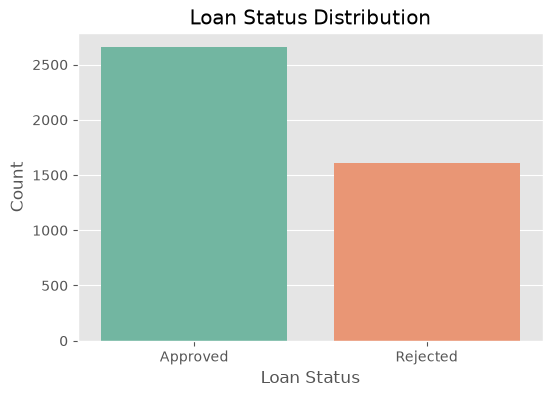

In [8]:
## EDA
## Loan Status Distribution
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x="loan_status",
    palette="Set2"
)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

In [9]:
## the percentages
df["loan_status"].value_counts(normalize=True)*100

loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64

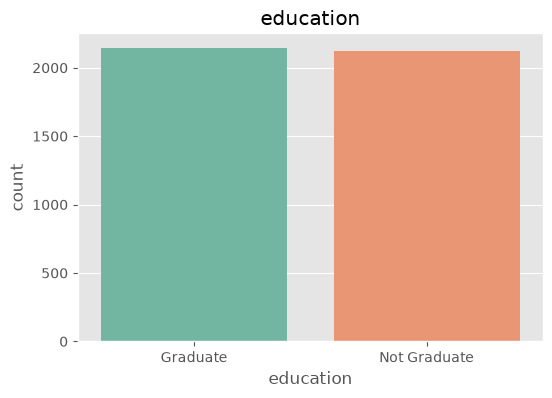

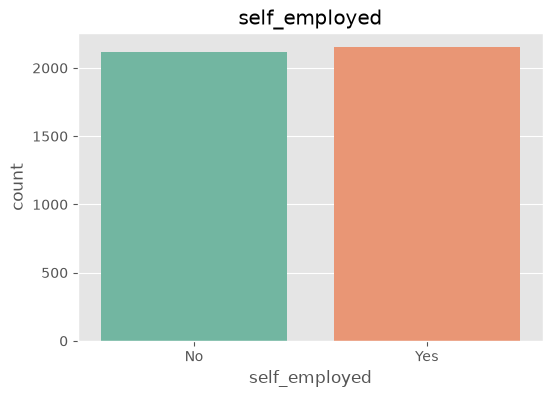

In [10]:
## Categorical columns
categorical_columns = [
    "education",
    "self_employed"
]
for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(
        data=df,
        x=col,
        palette="Set2"
    )
    plt.title(col)
    plt.show()

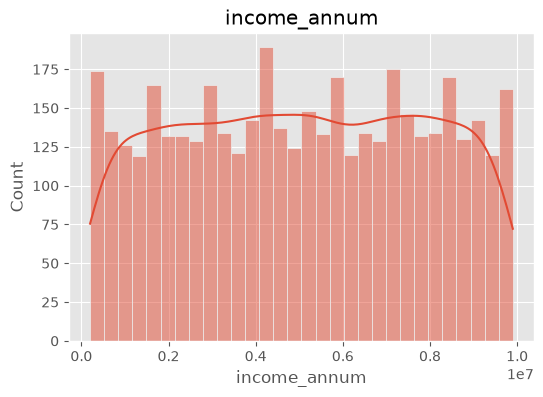

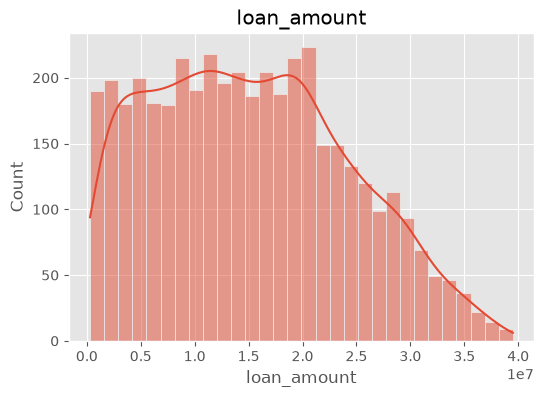

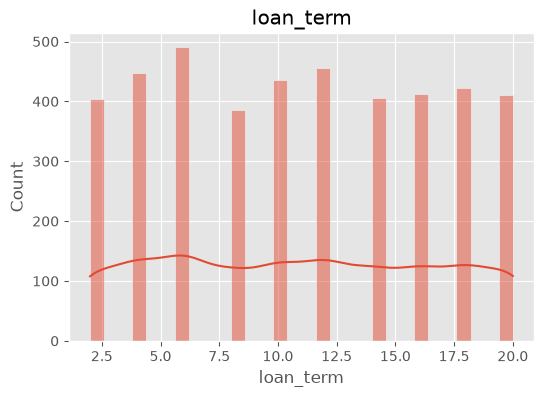

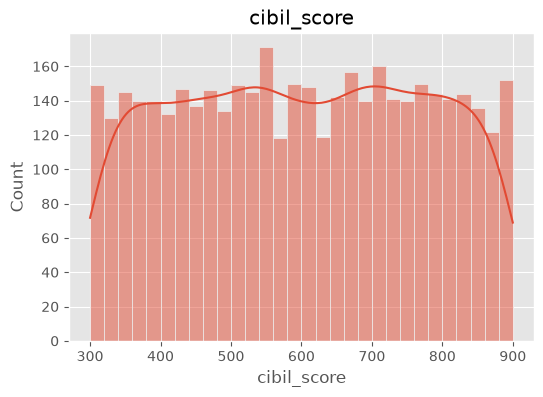

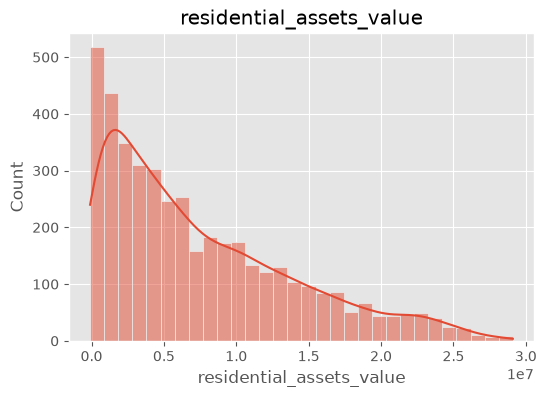

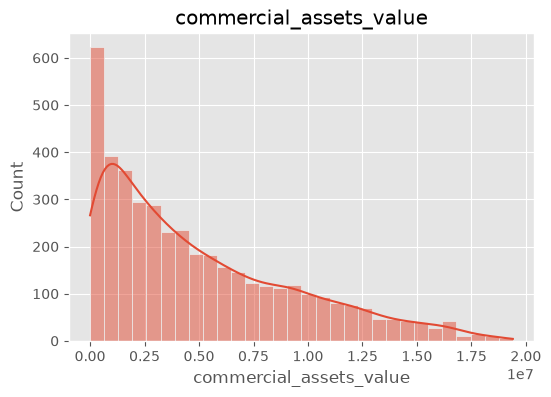

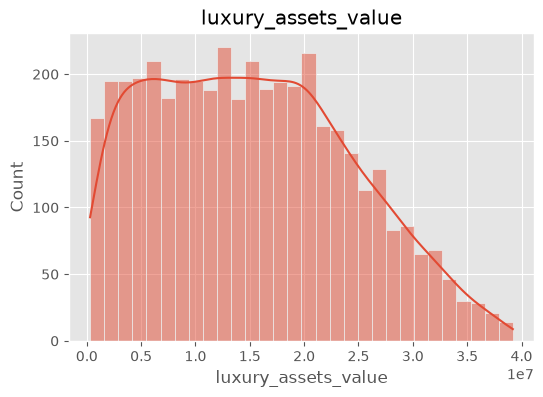

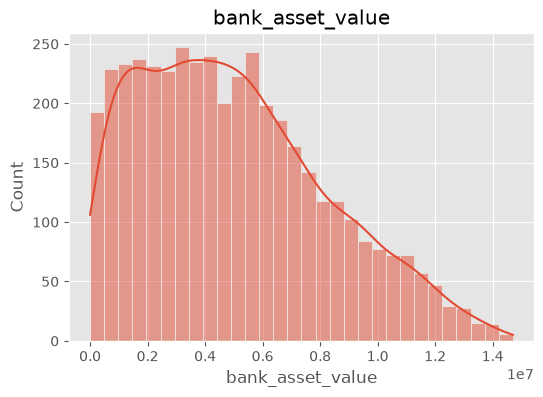

In [11]:
## Numerical Features
numerical_columns = [
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]
## Distribution
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )
    plt.title(col)
    plt.show()

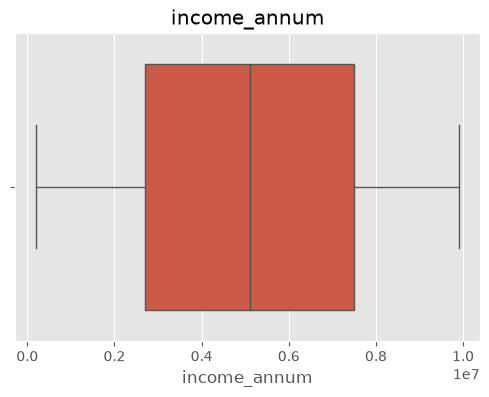

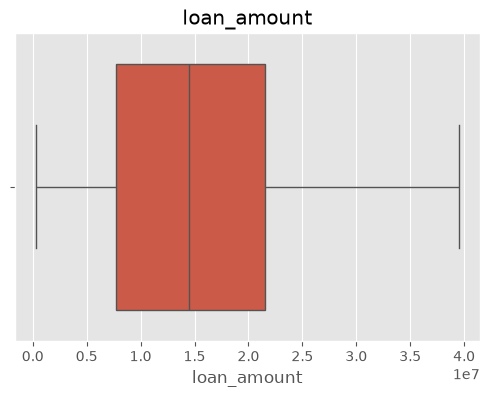

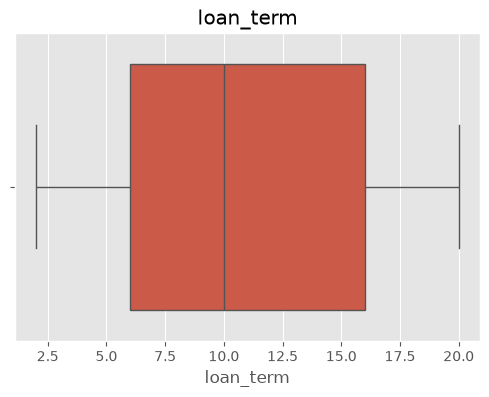

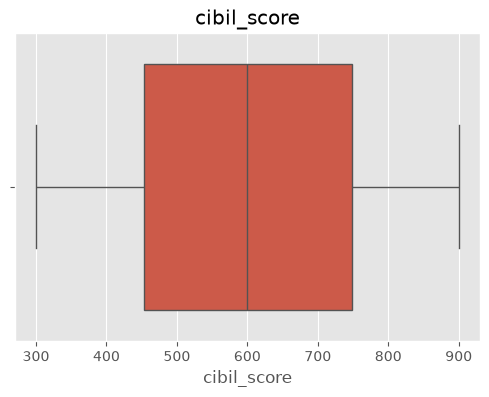

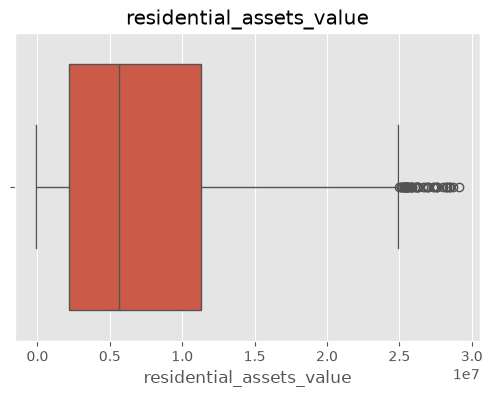

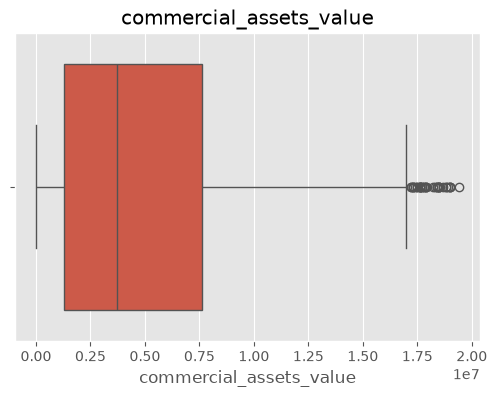

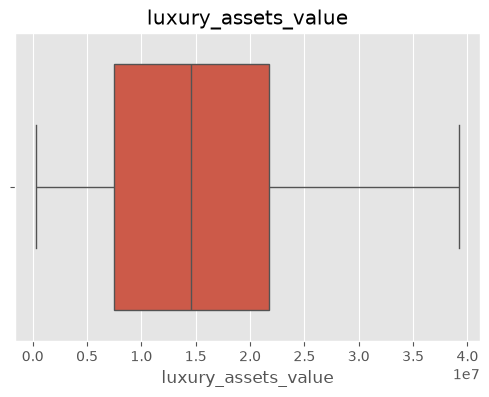

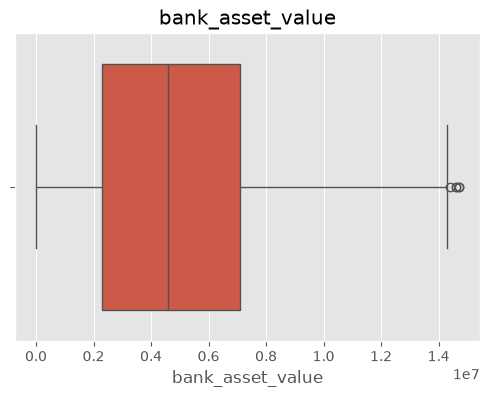

In [12]:
## Boxplots
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

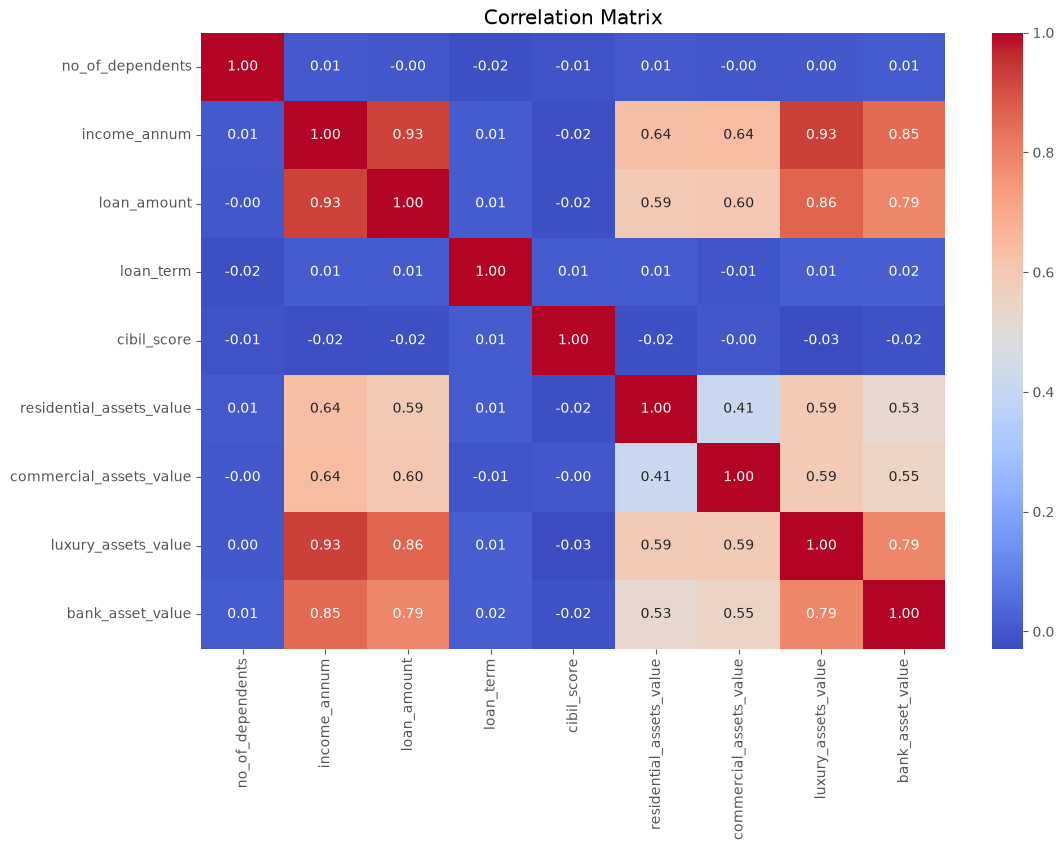

In [13]:
## Correlation Heatmap
df.drop("loan_id", axis=1, inplace=True)
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

In [14]:
# ==========================
# Separate Features & Target
# ==========================

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print(X.shape)
print(y.shape)
print(y.value_counts())
# ==========================
# Encode Categorical Columns
# ==========================

X["education"] = X["education"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

X["self_employed"] = X["self_employed"].map({
    "Yes": 1,
    "No": 0
})

y = y.map({
    "Approved": 1,
    "Rejected": 0
})
print(df["loan_status"].unique())
X.head()
## Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
## Verify shapes
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

(4269, 11)
(4269,)
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64
<ArrowStringArray>
['Approved', 'Rejected']
Length: 2, dtype: str
Training Features : (3415, 11)
Testing Features  : (854, 11)
Training Labels   : (3415,)
Testing Labels    : (854,)


In [15]:

X = df.drop("loan_status", axis=1)
y = df["loan_status"]
print(X.columns)

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'],
      dtype='str')


## Phase 3 – Model Building
## we'll train our first model: Logistic Regression.

Accuracy : 0.9133489461358314
Precision: 0.9208103130755064
Recall   : 0.9416195856873822
F1 Score : 0.931098696461825
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       323
           1       0.92      0.94      0.93       531

    accuracy                           0.91       854
   macro avg       0.91      0.90      0.91       854
weighted avg       0.91      0.91      0.91       854



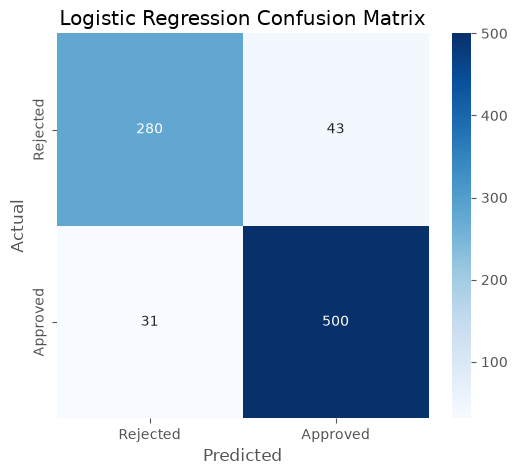

In [16]:
#Scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Train Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
#Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
#Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
#Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Accuracy : 0.9812646370023419
Precision: 0.9849340866290018
Recall   : 0.9849340866290018
F1 Score : 0.9849340866290018
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.98      0.98      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



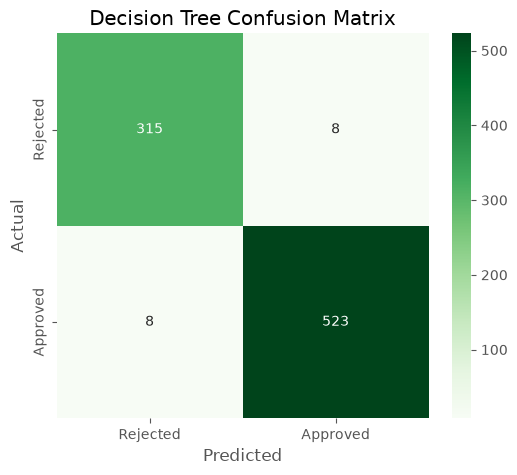

In [17]:
# ======================================
# Decision Tree Classifier
# ======================================

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
#Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Rejected","Approved"],
    yticklabels=["Rejected","Approved"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Accuracy : 0.9800936768149883
Precision: 0.9830827067669173
Recall   : 0.9849340866290018
F1 Score : 0.9840075258701787
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       323
           1       0.98      0.98      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



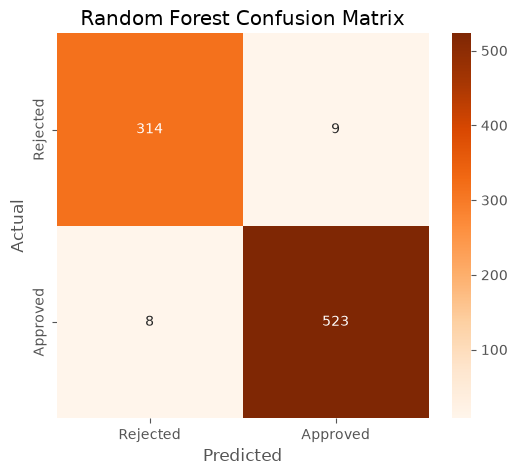

In [18]:
# ======================================
# Random Forest Classifier
# ======================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Rejected","Approved"],
    yticklabels=["Rejected","Approved"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Accuracy : 0.9824355971896955
Precision: 0.9831460674157303
Recall   : 0.9887005649717514
F1 Score : 0.9859154929577465
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



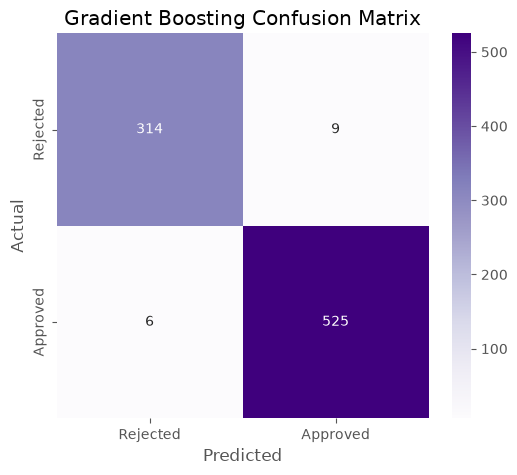

,Model,Accuracy,Precision,Recall,F1 Score
3,Gradient Boosting,0.982436,0.983146,0.988701,0.985915
1,Decision Tree,0.981265,0.984934,0.984934,0.984934
2,Random Forest,0.980094,0.983083,0.984934,0.984008
0,Logistic Regression,0.913349,0.920810,0.941620,0.931099


In [19]:
# ======================================
# Gradient Boosting Classifier
# ======================================

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
#Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))

print(classification_report(y_test, y_pred_gb))
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Rejected","Approved"],
    yticklabels=["Rejected","Approved"]
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

results

## Polishing the project

Gradient Boosting model saved successfully!


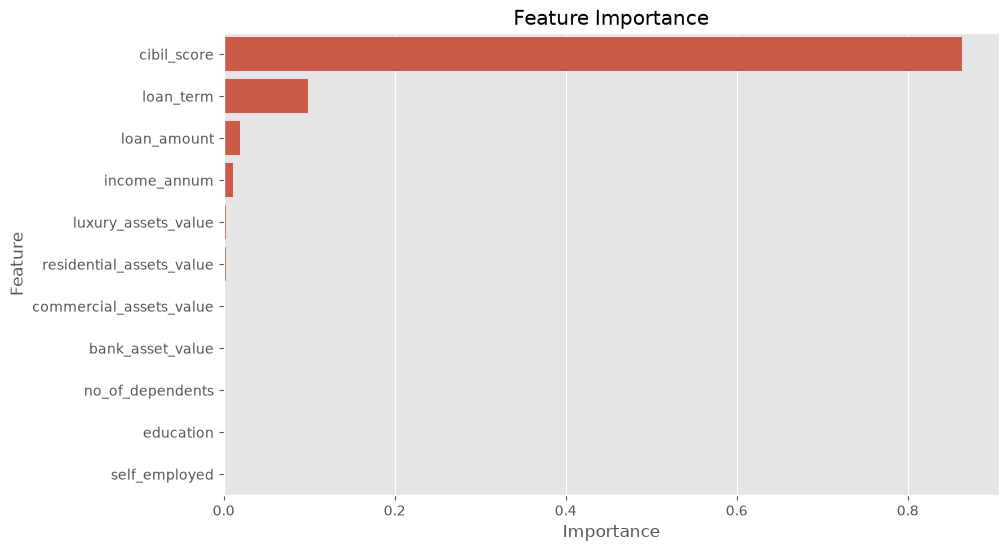

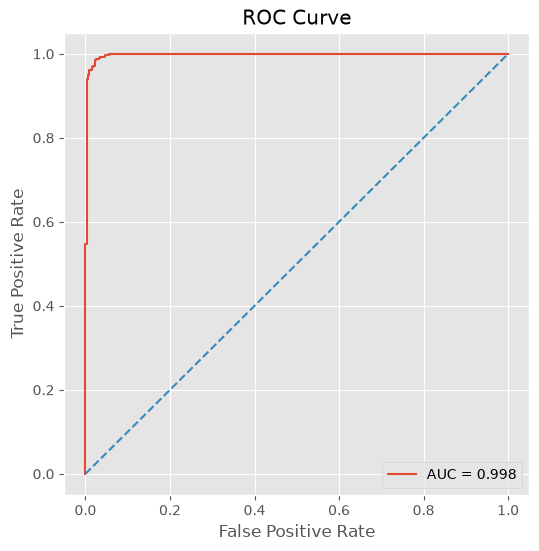

In [22]:
#Save the Best Model
import joblib

joblib.dump(gb_model, "../models/loan_approval_model.pkl")

print("Gradient Boosting model saved successfully!")
#Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance
#Visualize
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()
#ROC Curve
from sklearn.metrics import roc_curve, auc

y_prob = gb_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [21]:
import sys
import sklearn

print("Python:", sys.executable)
print("Scikit-learn:", sklearn.__version__)

Python: c:\ML-PROJECTS-KUDBUD\Loan-Approval-Prediction\venv\Scripts\python.exe
Scikit-learn: 1.9.0
